In [167]:
import pandas as pd 
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("project2_customer_shopping_raw.csv")
df

,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Purchase_Date,Payment_Method
0,1001,46.0,Male,Mumbai,Headphones,Audio,5.0,799,2025-04-13,Credit Card
1,1002,40.0,Male,Mumbai,Keyboard,Accessories,5.0,599,2025-04-14,Cash
2,1003,39.0,Male,Delhi,Keyboard,Accessories,4.0,999,2025-02-07,Credit Card
3,1004,NaN,Male,Bangalore,Headphones,Audio,2.0,999,2025-03-30,UPI
4,1005,59.0,Female,Bangalore,Keyboard,Accessories,4.0,1999,2025-01-15,Credit Card
...,...,...,...,...,...,...,...,...,...,...
118,1119,38.0,Female,Raipur,Webcam,Electronics,5.0,299,2025-01-12,Credit Card
119,1120,51.0,Male,Hyderabad,Webcam,Electronics,2.0,799,2025-06-04,UPI
120,1011,51.0,Female,Hyderabad,Headphones,Audio,4.0,999,2025-04-05,Cash
121,1056,39.0,Female,Delhi,USB Cable,Accessories,1.0,599,2025-06-19,Credit Card


In [62]:
df[df.duplicated()] 

,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Purchase_Date,Payment_Method
120,1011,51.0,Female,Hyderabad,Headphones,Audio,4.0,999,2025-04-05,Cash
121,1056,39.0,Female,Delhi,USB Cable,Accessories,1.0,599,2025-06-19,Credit Card
122,1091,37.0,Female,Pune,Headphones,Audio,1.0,1499,2025-01-01,Debit Card


In [63]:
df[df['Age'].isnull()] 

,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Purchase_Date,Payment_Method
3,1004,NaN,Male,Bangalore,Headphones,Audio,2.0,999,2025-03-30,UPI
17,1018,NaN,Female,Hyderabad,USB Cable,Accessories,3.0,499,2025-04-11,Debit Card
64,1065,NaN,Female,Hyderabad,Laptop Bag,Accessories,4.0,799,2025-05-24,Credit Card


In [64]:
df["Gender"].unique()

array(['Male', 'Female', 'male'], dtype=object)

In [65]:
df["City"].unique()

array(['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', nan, 'Raipur', 'Pune'],
      dtype=object)

In [66]:
df["Category"].unique()

array(['Audio', 'Accessories', 'Electronics', 'accessories'], dtype=object)

In [67]:
df["Payment_Method"].unique()

array(['Credit Card', 'Cash', 'UPI', 'Debit Card', nan], dtype=object)

In [68]:
df["Product"].unique()

array(['Headphones', 'Keyboard', 'Webcam', 'USB Cable', 'Laptop Bag',
       'Wireless Mouse'], dtype=object)

In [185]:
df["Gender"].value_counts(dropna=False)

Gender
Female    68
Male      54
Name: count, dtype: int64

In [70]:
df["Quantity"].unique()

array([ 5.,  4.,  2.,  1.,  3., nan,  0.])

In [71]:
df["Age"].unique()

array([46., 40., 39., nan, 59., 20., 42., 19., 31., 23., 51., 41., 25.,
       50., 26., 49., 53., 28., 30., 29., 57., -4., 18., 52., 35., 21.,
       34., 47., 22., 58., 43., 24., 33., 60., 56., 54., 38., 27., 36.,
       45., 48., 37., 55.])

In [72]:
df["Price"].unique()

array(['799', '599', '999', '1999', '299', 'unknown', '1499', '499',
       '399'], dtype=object)

In [73]:
df = df.copy()
df["Age"] = df["Age"].fillna(df["Age"].median())

In [74]:
df["City"] = df["City"].fillna("Unknown")

In [75]:
df.isnull().sum()

Customer_ID       0
Age               0
Gender            0
City              0
Product           0
Category          0
Quantity          2
Price             0
Purchase_Date     0
Payment_Method    3
dtype: int64

In [76]:
df[df["Quantity"].isnull()]

,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Purchase_Date,Payment_Method
21,1022,53.0,Male,Mumbai,USB Cable,Accessories,NaN,999,2025-01-28,Credit Card
72,1073,43.0,Female,Pune,Laptop Bag,Accessories,NaN,399,2025-03-31,Credit Card


In [77]:
df[df["Quantity"] <= 0]

,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Purchase_Date,Payment_Method
79,1080,29.0,Male,Raipur,Headphones,Audio,0.0,599,2025-01-09,Debit Card


In [78]:
df["Quantity"].value_counts(dropna=False).sort_index()

Quantity
0.0     1
1.0    26
2.0    18
3.0    26
4.0    24
5.0    26
NaN     2
Name: count, dtype: int64

In [79]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

In [80]:
df = df[df["Quantity"] > 0]

In [81]:
df["Quantity"].min()

1.0

In [82]:
df["Price"].unique()

array(['799', '599', '999', '1999', '299', 'unknown', '1499', '499',
       '399'], dtype=object)

In [83]:
df["Price"].dtype

dtype('O')

In [84]:
df[df["Price"] == 'unknown']

,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Purchase_Date,Payment_Method
6,1007,42.0,Female,Hyderabad,Headphones,Audio,2.0,unknown,2025-01-09,Credit Card
38,1039,52.0,Female,Hyderabad,Headphones,Audio,1.0,unknown,2025-06-02,UPI


In [109]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [110]:
df["Price"].median()

799.0

In [111]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Price"].dtype

dtype('float64')

In [112]:
df["Price"].isnull().sum()

np.int64(2)

In [113]:
df["Price"] = df["Price"].fillna(df["Price"].median())

In [114]:
df["Price"].isnull().sum() , df["Price"].dtype

(np.int64(0), dtype('float64'))

In [116]:
df.shape

(122, 10)

In [117]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Product', 'Category',
       'Quantity', 'Price', 'Purchase_Date', 'Payment_Method'],
      dtype='object')

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122 entries, 0 to 122
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     122 non-null    int64  
 1   Age             122 non-null    float64
 2   Gender          122 non-null    object 
 3   City            122 non-null    object 
 4   Product         122 non-null    object 
 5   Category        122 non-null    object 
 6   Quantity        122 non-null    float64
 7   Price           122 non-null    float64
 8   Purchase_Date   122 non-null    object 
 9   Payment_Method  119 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 10.5+ KB


In [119]:
df.isnull().sum()

Customer_ID       0
Age               0
Gender            0
City              0
Product           0
Category          0
Quantity          0
Price             0
Purchase_Date     0
Payment_Method    3
dtype: int64

In [120]:
df.duplicated().sum()

np.int64(3)

In [128]:
df["Gender"] = df["Gender"].replace("male", "Male")
df["Gender"].value_counts(dropna=False)

Gender
Female    68
Male      54
Name: count, dtype: int64

In [130]:
df["Category"] = df["Category"].replace("accessories","Accessories")
df["Category"].value_counts(dropna=False)

Category
Accessories    82
Electronics    21
Audio          19
Name: count, dtype: int64

In [133]:
df["Payment_Method"] = df["Payment_Method"].fillna("Unknown")
df["Payment_Method"].value_counts(dropna=False)

Payment_Method
Credit Card    40
Cash           28
Debit Card     26
UPI            25
Unknown         3
Name: count, dtype: int64

In [136]:
df.loc[df["Age"] <= 0 , "Age"] = df["Age"].median()
df["Age"].min()

,Customer_ID,Age,Gender,City,Product,Category,Quantity,Price,Purchase_Date,Payment_Method


In [144]:
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122 entries, 0 to 122
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Customer_ID     122 non-null    int64         
 1   Age             122 non-null    float64       
 2   Gender          122 non-null    object        
 3   City            122 non-null    object        
 4   Product         122 non-null    object        
 5   Category        122 non-null    object        
 6   Quantity        122 non-null    float64       
 7   Price           122 non-null    float64       
 8   Purchase_Date   122 non-null    datetime64[ns]
 9   Payment_Method  122 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 10.5+ KB


In [146]:
df["Gender"].value_counts()

Gender
Female    68
Male      54
Name: count, dtype: int64

In [147]:
df["Category"].value_counts()

Category
Accessories    82
Electronics    21
Audio          19
Name: count, dtype: int64

In [148]:
df["Product"].value_counts()

Product
Keyboard          22
USB Cable         22
Laptop Bag        22
Webcam            21
Headphones        19
Wireless Mouse    16
Name: count, dtype: int64

In [150]:
df["Total_Sales"] = df["Quantity"] * df["Price"]
df["Total_Sales"]

0      3995.0
1      2995.0
2      3996.0
3      1998.0
4      7996.0
        ...  
118    1495.0
119    1598.0
120    3996.0
121     599.0
122    1499.0
Name: Total_Sales, Length: 122, dtype: float64

In [156]:
df.groupby("Product")["Total_Sales"].sum()

Product
Headphones        53539.0
Keyboard          62038.0
Laptop Bag        73830.0
USB Cable         48439.0
Webcam            66929.0
Wireless Mouse    48553.0
Name: Total_Sales, dtype: float64

In [158]:
df.groupby("City")["Total_Sales"].sum().idxmax()

'Bangalore'

In [160]:
df["Month"] = df["Purchase_Date"].dt.month
df["Month"].value_counts().sort_index()

Month
1    17
2    14
3    17
4    24
5    22
6    28
Name: count, dtype: int64

In [161]:
df.groupby("Month")["Total_Sales"].sum()

Month
1     35550.0
2     42455.0
3     55944.0
4     60825.0
5    100324.0
6     58230.0
Name: Total_Sales, dtype: float64

In [163]:
df["Total_Sales"].mean()

np.float64(2896.1311475409834)

In [164]:
df.groupby("Category")["Total_Sales"].mean()

Category
Accessories    2839.756098
Audio          2817.842105
Electronics    3187.095238
Name: Total_Sales, dtype: float64

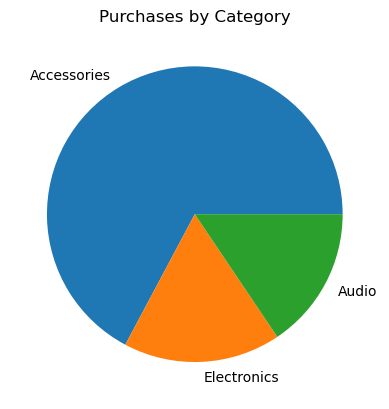

Category
Accessories    82
Electronics    21
Audio          19
Name: count, dtype: int64

In [171]:
counts = df["Category"].value_counts()

plt.pie(counts, labels=counts.index)
plt.title("Purchases by Category")
plt.show()
counts

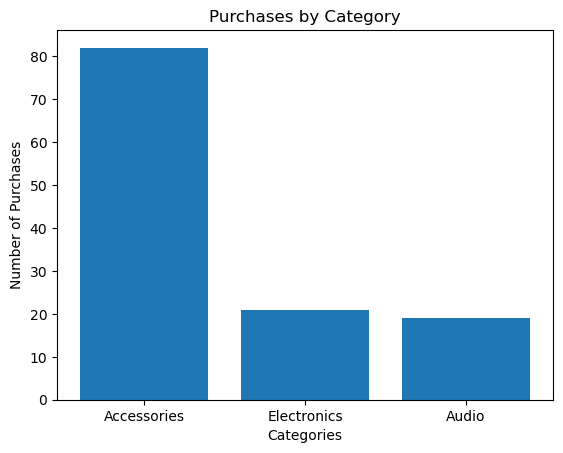

Category
Accessories    82
Electronics    21
Audio          19
Name: count, dtype: int64

In [174]:
plt.bar(counts.index, counts)
plt.xlabel("Categories")
plt.ylabel("Number of Purchases")
plt.title("Purchases by Category")
plt.show()
counts

Product
Laptop Bag        73830.0
Webcam            66929.0
Keyboard          62038.0
Headphones        53539.0
Wireless Mouse    48553.0
USB Cable         48439.0
Name: Total_Sales, dtype: float64

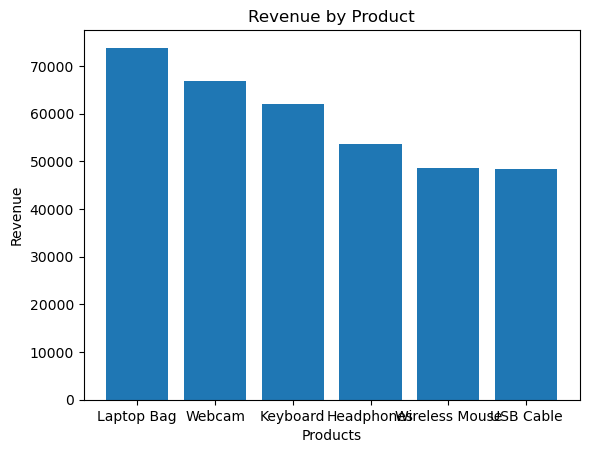

In [178]:
revenue_by_product = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)
plt.bar(revenue_by_product.index,revenue_by_product)
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.title("Revenue by Product")
plt.show
revenue_by_product

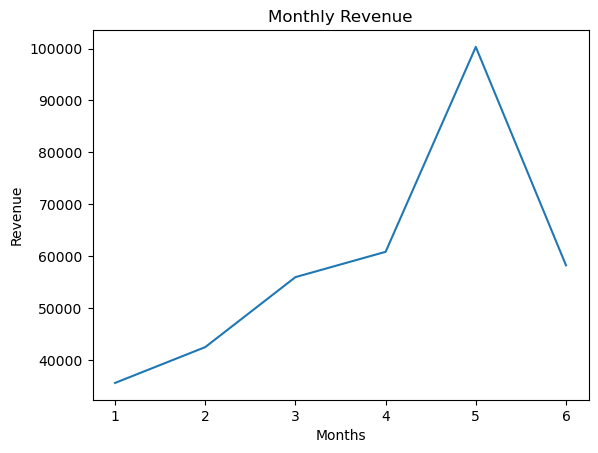

Month
1     35550.0
2     42455.0
3     55944.0
4     60825.0
5    100324.0
6     58230.0
Name: Total_Sales, dtype: float64

In [181]:
monthly_revenue = df.groupby("Month")["Total_Sales"].sum().sort_index()
plt.plot(monthly_revenue.index,monthly_revenue)
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.show()
monthly_revenue

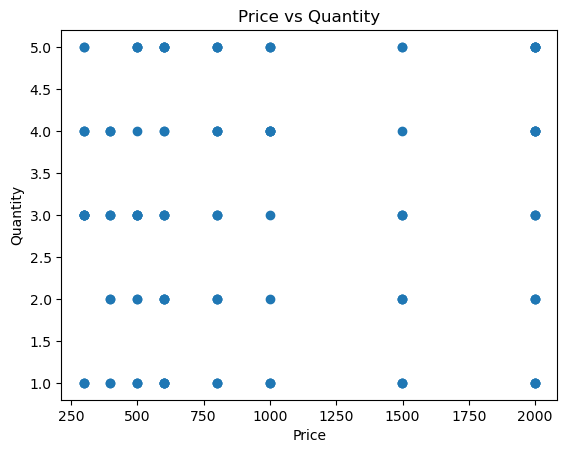

In [182]:
plt.scatter(df["Price"], df["Quantity"])
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.title("Price vs Quantity")
plt.show()

In [183]:
df["Total_Sales"].sum()

np.float64(353328.0)

In [184]:
df.to_csv("customer_shopping_cleaned.csv", index=False)

In [ ]:
## Key Insights

#- Total revenue generated was ₹353,328 across 122 transactions.
#- Accessories was the most purchased category with 82 purchases.
#- Laptop Bag generated the highest product revenue at ₹73,830.
#- Bangalore generated the highest total sales among the cities.
#- June recorded the highest number of purchases with 28 transactions.
#- May generated the highest monthly revenue.
#- Electronics had the highest average transaction value among the categories.